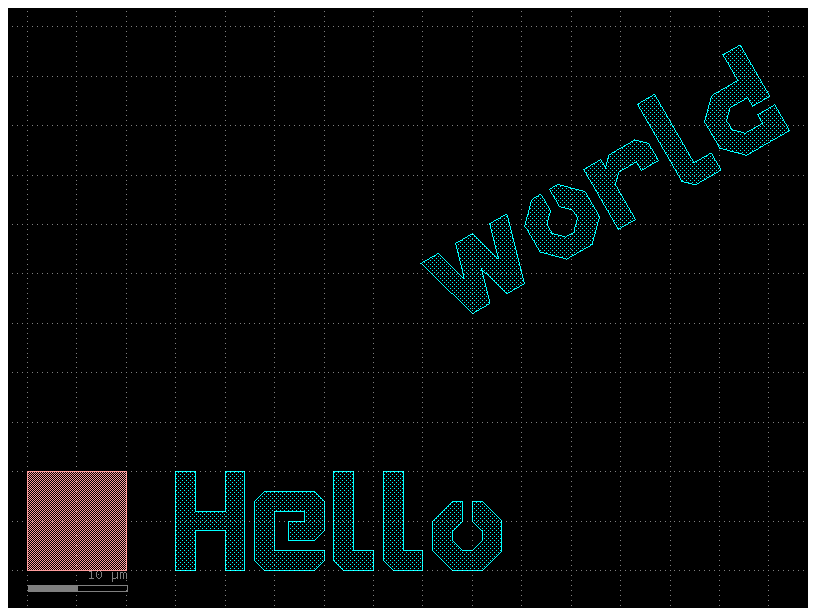

In [1]:
import gdsfactory as gf
import component_library as cp

# Activate the generic PDK
gf.gpdk.PDK.activate()

# Create a new component
c = gf.Component()

# Add a rectangle
r = gf.components.rectangle(size=(10, 10), layer=(1, 0))
rect = c.add_ref(r)

# Add text elements
t1 = gf.components.text("Hello", size=10, layer=(2, 0))
t2 = gf.components.text("world", size=10, layer=(2, 0))

text1 = c.add_ref(t1)
text2 = c.add_ref(t2)

# Position elements
text1.xmin = rect.xmax + 5
text2.xmin = text1.xmax + 2
text2.rotate(30)

# Show the result
c.plot()

In [6]:
c = gf.Component()

y_pos = 0
for i in range(4):
    wgd = c << cp.straight(width=2,length=20)
    wgd.move((0,y_pos))
    y_pos += 10
c.dmove((20,20))
c << gf.components.bend_euler(radius=5.0, width=0.5, angle=-90, npoints=720, layer=(1, 0))

c.show()

DPort(self.name='o2', self.width=0.5, trans=r0 *1 15.5,0.625, layer=WG (1/0), port_type=optical)


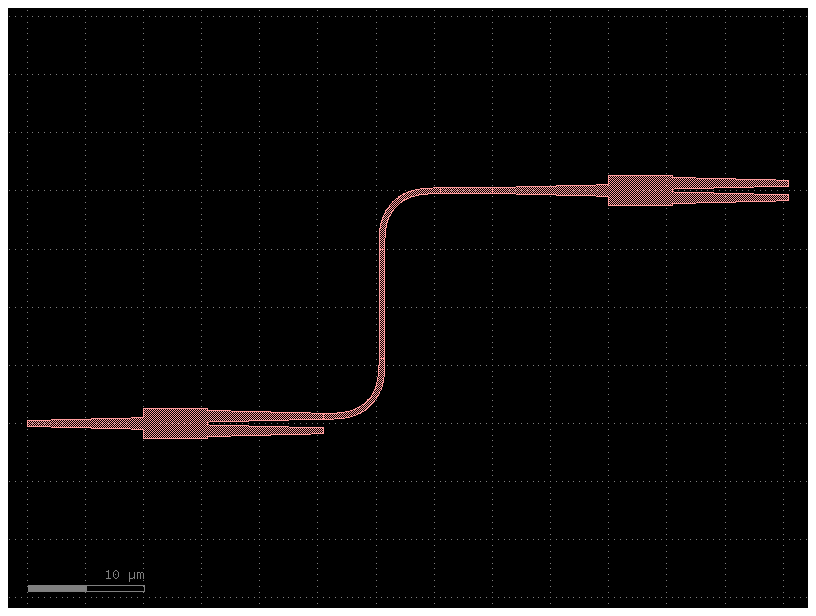

In [8]:
c = gf.Component()
mmi1 = c << gf.components.mmi1x2()
mmi2 = c << gf.components.mmi1x2()
mmi2.move((40, 20))
gf.routing.route_single(c, mmi1.ports["o2"], mmi2.ports["o1"], radius=5, cross_section="strip")
print(mmi1.ports["o2"])
c.plot()

[DPort(self.name='o1', self.width=2.0, trans=r270 *1 0,0, layer=WG (1/0), port_type=optical), DPort(self.name='o2', self.width=2.0, trans=r90 *1 0,10, layer=WG (1/0), port_type=optical)]
10.0


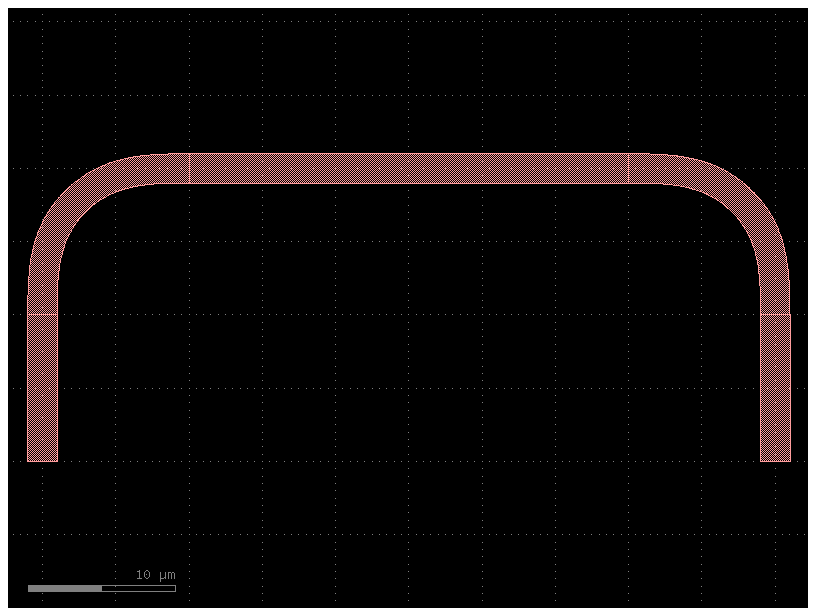

In [27]:
CS = gf.cross_section.cross_section(width=2.0, offset=0, layer='WG', sections=None, port_names=('o1', 'o2'), port_types=('optical', 'optical'), bbox_layers=None, bbox_offsets=None, cladding_layers=None, cladding_offsets=None, cladding_simplify=None, cladding_centers=None, radius=10.0, radius_min=7.0, main_section_name='_default')
xs = gf.get_cross_section(CS)
c = gf.Component()
wvgd1 = c << gf.components.straight(length=10.0, cross_section=CS)
wvgd2 = c << gf.components.straight(length=10.0, cross_section=CS)

wvgd1.rotate(90)
wvgd2.rotate(90)
wvgd2.movex(50)

gf.routing.route_single(c, wvgd1.ports["o2"], wvgd2.ports["o2"], radius=10, cross_section=CS)

ports_list = gf.port.get_ports_list(wvgd1)
print(ports_list)
print(xs.radius)
#c.add_port()

c.draw_ports()
c.plot()

In [1]:
import gdsfactory as gf
import component_library as cp

gf.gpdk.PDK.activate()

CS = gf.cross_section.cross_section(width=2.0, offset=0, layer='WG', sections=None, port_names=('o1', 'o2'), port_types=('optical', 'optical'), bbox_layers=None, bbox_offsets=None, cladding_layers=None, cladding_offsets=None, cladding_simplify=None, cladding_centers=None, radius=10.0, radius_min=7.0, main_section_name='_default')

c =  cp.loopback(pitch=127, length=50, cross_section=CS)

c.show()

In [6]:
import gdsfactory as gf
import component_library as cp

gf.gpdk.PDK.activate()

CS = gf.cross_section.cross_section(width=0.8, offset=0, layer='WG', sections=None, port_names=('o1', 'o2'), port_types=('optical', 'optical'), bbox_layers=None, bbox_offsets=None, cladding_layers=None, cladding_offsets=None, cladding_simplify=None, cladding_centers=None, radius=10.0, radius_min=7.0, main_section_name='_default')


gr = cp.grate_coupler(cross_section=CS)



c = cp.grate_coupler_array(gr=gr,cross_section=CS)

mmi = c << cp.mmi2x2(width_mmi=5.0, length_mmi= 30.0, cross_section=CS)

mmi.movex(-15.0)
mmi.movey(100.0)

c.add_port("mo1", port=mmi.ports["o1"])
c.add_port("mo2", port=mmi.ports["o2"])
c.add_port("mo3", port=mmi.ports["o3"])
c.add_port("mo4", port=mmi.ports["o4"])

ports1 = [c.ports[f"o{i}"] for i in [1,2]]
ports2 = [mmi.ports[f"o{i}"] for i in [2,1]]
gf.routing.route_bundle(component=c, ports1=ports1, ports2=ports2, cross_section=CS, separation=1)

ports1 = [c.ports[f"o{i}"] for i in [3,4]]
ports2 = [mmi.ports[f"o{i}"] for i in [4,3]]
gf.routing.route_bundle(component=c, ports1=ports1, ports2=ports2, cross_section=CS, separation=1)
#gf.routing.route_single(c, c.ports["o2"], mmi.ports["o1"], radius=10, cross_section=CS)
#gf.routing.route_single(c, c.ports["o1"], mmi.ports["o2"], radius=10, cross_section=CS)
#gf.routing.route_single(c, c.ports["o3"], mmi.ports["o4"], radius=10, cross_section=CS)
#gf.routing.route_single(c, c.ports["o4"], mmi.ports["o3"], radius=10, cross_section=CS)

c.show()

In [18]:
import numpy as np
MMI_LENGTH = np.arange(20.0,40.1,5.0)
MMI_WIDTH = np.arange(8.0,9.1,0.5)

print(MMI_LENGTH)
print(MMI_WIDTH)

MMI_arr = [[None for _ in range(len(MMI_WIDTH))] for _ in range(len(MMI_LENGTH))]

MMI_arr[0][2] = 1
print(MMI_arr)
print(MMI_WIDTH[0])

[20. 25. 30. 35. 40.]
[8.  8.5 9. ]
[[None, None, 1], [None, None, None], [None, None, None], [None, None, None], [None, None, None]]
8.0


In [14]:
arr = [[None for _ in range(2)] for _ in range(2)]

arr[0][1] = cp.grate_coupler(cross_section=CS)
print(arr)

[[None, Component(name=grating_coupler_elliptical_gdsfactorypcomponentspgratin_edd5c257$7, ports=['o1', 'o2'], pins=[], instances=[], locked=False, kcl=DEFAULT)], [None, None]]


Spiral length: 2635.8360000000002 µm


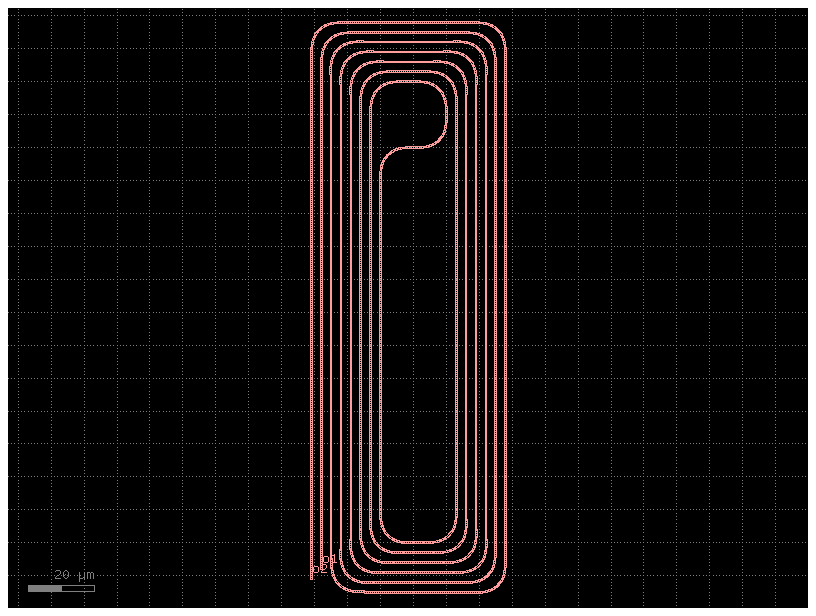

In [8]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.spiral(length=100, bend='bend_euler', straight='straight', cross_section='strip', spacing=3, n_loops=6).copy()
c.rotate(-90)
c.draw_ports()
c.plot()

length = c.info['length']
print(f"Spiral length: {length} µm")

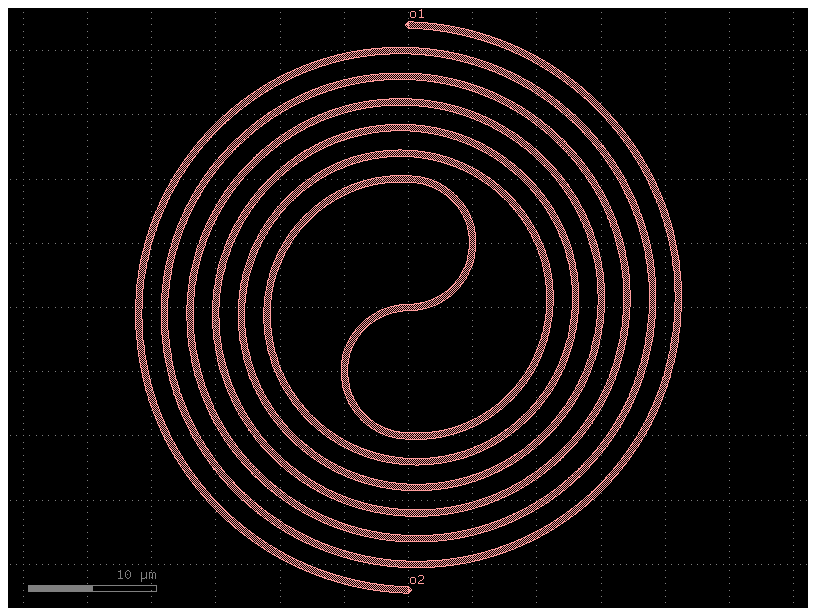

In [5]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.spiral_double(min_bend_radius=10, separation=2, number_of_loops=3, npoints=1000, cross_section='strip', bend='bend_circular').copy()
c.draw_ports()
c.plot()

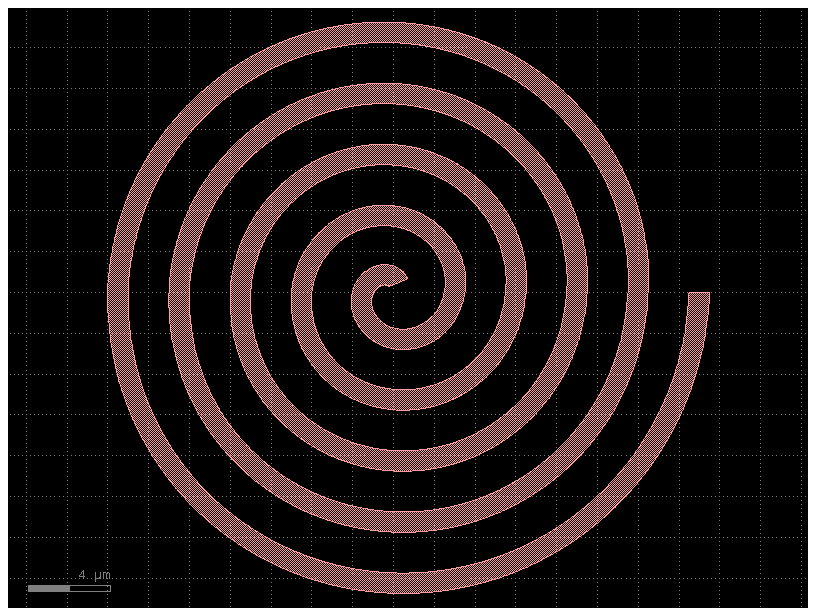

In [7]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.spiral_archimedes(width=1, n_turns=5, separation=2, angle_resolution=2, layer='WG').copy()
c.draw_ports()
c.plot()

bend path length: 11.206 µm
10.0
1537.1983559999999


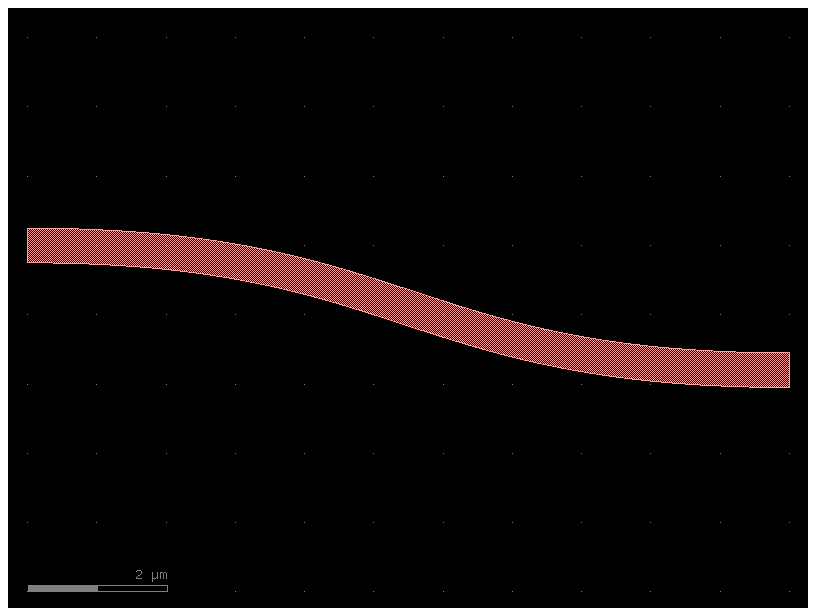

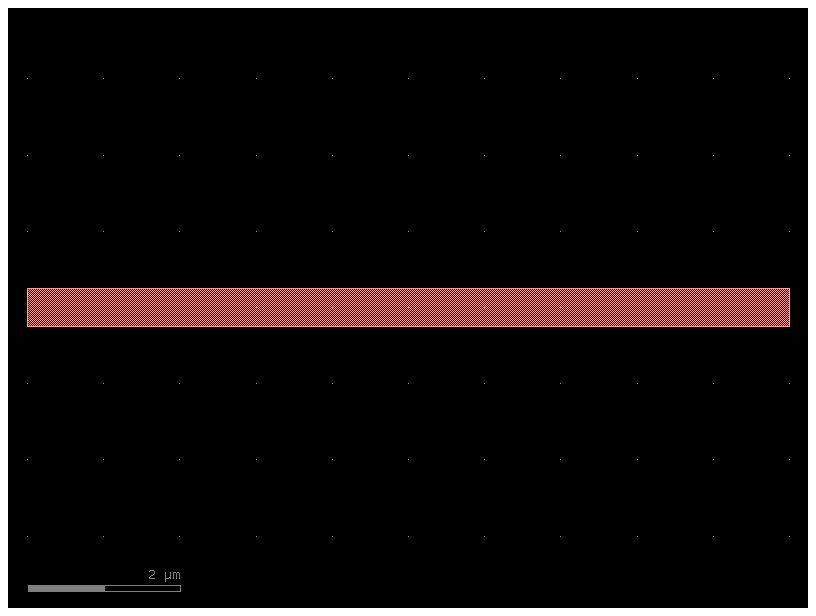

In [1]:
import gdsfactory as gf
import component_library as cp

gf.gpdk.PDK.activate()

mmi = cp.mmi2x2(width_mmi = 8.0, length_mmi=30.0)


c, dL = cp.amzi_2x2(mmi=mmi,spiral_length=20.0)

a = gf.components.bend_s(size=(11.0, -1.8),
    npoints = 99,
    cross_section = "strip")

r = gf.Component()

r.add_port(name="o1", center=[0, 0], orientation=0, layer="WG",cross_section="strip")
r.add_port(name="o2", center=[10, 0], orientation=180, layer="WG",cross_section="strip")

route = gf.routing.route_single(r,r.ports["o1"], r.ports["o2"], cross_section="strip")
#a.draw_ports()
c.show()
a.plot()
r.plot()
length = a.info['length']
print(f"bend path length: {length} µm")
print(route.length/1000)
print(dL)